Starting EKF Simulation...


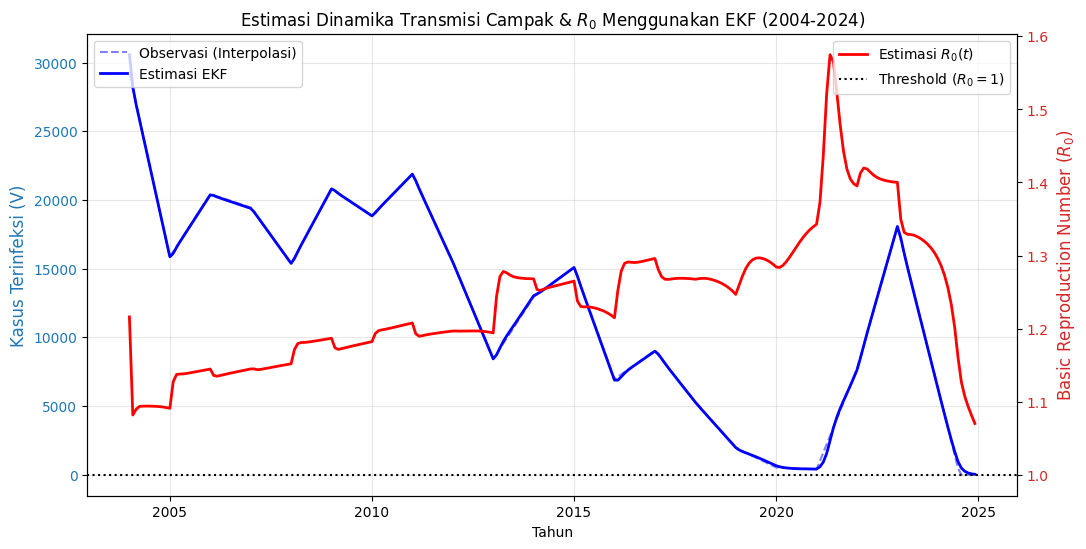

Analisis Selesai. Data disimpan ke 'Hasil_Analisis_EKF_Campak.csv'


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. DATA PREPARATION ---
def load_and_prep_data(filepath):
    # Load dataset
    df = pd.read_csv(filepath)

    # Cleaning: Remove commas and convert to numeric
    df['Measles_Reported_cases'] = df['Measles_Reported_cases'].astype(str).str.replace(',', '').astype(float)

    # Normalize vaccination percentages to [0, 1]
    df['p'] = df['WUENIC_Measles_containing vaccine_1st_dose(%)'] / 100.0
    df['q'] = df['WUENIC_Measles_containing vaccine_2nd_dose(%)'] / 100.0

    # Sort by year
    df = df.sort_values('Year').reset_index(drop=True)

    # INTERPOLATION: Convert Annual Data to Monthly Steps
    # EKF needs smaller time steps for ODE stability
    years = df['Year'].values
    months = []
    for y in years:
        for m in range(12):
            months.append(y + m/12.0)

    df_monthly = pd.DataFrame({'Time': months})

    # Linear Interpolation functions
    f_p = interp1d(df['Year'], df['p'], kind='linear', fill_value="extrapolate")
    f_q = interp1d(df['Year'], df['q'], kind='linear', fill_value="extrapolate")
    f_v = interp1d(df['Year'], df['Measles_Reported_cases'], kind='linear', fill_value="extrapolate")

    # Apply interpolation
    df_monthly['p'] = f_p(df_monthly['Time'])
    df_monthly['q'] = f_q(df_monthly['Time'])
    df_monthly['V_obs'] = f_v(df_monthly['Time']).clip(min=0) # Ensure non-negative

    return df_monthly

# --- 2. MODEL PARAMETERS ---
# Population and Rate Constants (Estimates for Measles)
N = 270000000.0   # Total Population (Approx Indonesia)
mu = 0.014        # Natural death rate (approx 1/70 years)
Lambda = mu * N   # Birth rate (assuming stable population for simplicity)
r = 26.0          # Recovery rate (Measles recovery ~2 weeks -> 26/year)
epsilon = 0.1     # Isolation rate (assumed low for Measles)
d = 0.001         # Disease induced death rate
phi = 12.0        # Recovery from quarantine
kappa = 0.9       # Vaccine efficacy
alpha = 0.5       # Failure ratio (Booster efficacy factor)
dt = 1.0/12.0     # Time step (1 month)

# --- 3. EXTENDED KALMAN FILTER (EKF) ---
def run_ekf(df):
    # Initialization
    # State Vector x = [U, V, W, Z, beta]
    # We augment beta (transmission rate) as a state to estimate it
    U0 = 0.9 * N
    V0 = df['V_obs'].iloc[0]
    W0 = 0.0
    Z0 = N - U0 - V0
    beta0 = 300.0 # Initial guess for contact rate

    x = np.array([U0, V0, W0, Z0, beta0])

    # Covariance Matrix P (Confidence in initial estimate)
    P = np.eye(5) * 1e4
    P[4, 4] = 1e2 # Tighter confidence for beta

    # Process Noise Q (Model uncertainty)
    # Allow beta (index 4) to "walk" (Random Walk Process)
    Q = np.diag([1e2, 1e2, 1e2, 1e2, 10.0])

    # Measurement Noise R (Data noise)
    R_noise = np.array([[1e6]]) # High noise assumed in reported cases

    # Measurement Matrix H (We only observe V, index 1)
    H = np.zeros((1, 5))
    H[0, 1] = 1

    results = []
    R0_list = []

    print("Starting EKF Simulation...")

    for index, row in df.iterrows():
        p_t = row['p']
        q_t = row['q']
        y_obs = row['V_obs'] # The actual measurement

        # --- A. PREDICT STEP (Time Update) ---
        U, V, W, Z, beta = x
        C_vac = (1 - q_t) + alpha * q_t # Vaccine Factor

        # ODE System (Euler Integration)
        # dU/dt = ...
        U_new = U + dt * ((1 - kappa * p_t) * Lambda - beta * C_vac * U * V / N - mu * U)
        # dV/dt = ...
        V_new = V + dt * (beta * C_vac * U * V / N - (r + epsilon + mu + d) * V)
        # dW/dt = ...
        W_new = W + dt * (epsilon * V - (phi + mu + d) * W)
        # dZ/dt = ...
        Z_new = Z + dt * (kappa * p_t * Lambda + r * V + phi * W - mu * Z)
        # d(beta)/dt = 0 + noise (Random Walk)
        beta_new = beta

        x_pred = np.array([U_new, V_new, W_new, Z_new, beta_new])

        # Calculate Jacobian Matrix F (Linearization)
        # Partial derivatives of the system w.r.t states
        F = np.eye(5)

        # d(dot_U)/d...
        F[0, 0] = 1 + dt * (-beta * C_vac * V / N - mu) # dU/dU
        F[0, 1] = dt * (-beta * C_vac * U / N)          # dU/dV
        F[0, 4] = dt * (-C_vac * U * V / N)             # dU/dbeta (Crucial!)

        # d(dot_V)/d...
        F[1, 0] = dt * (beta * C_vac * V / N)           # dV/dU
        F[1, 1] = 1 + dt * (beta * C_vac * U / N - (r + epsilon + mu + d)) # dV/dV
        F[1, 4] = dt * (C_vac * U * V / N)              # dV/dbeta

        # Other derivatives (Linear parts)
        F[2, 1] = dt * epsilon
        F[2, 2] = 1 + dt * (-(phi + mu + d))
        F[3, 1] = dt * r
        F[3, 2] = dt * phi
        F[3, 3] = 1 + dt * (-mu)

        # Predicted Covariance
        P_pred = F @ P @ F.T + Q

        # --- B. UPDATE STEP (Measurement Update) ---
        # Innovation (Residual)
        y_pred = x_pred[1] # Predicted V
        y_residual = y_obs - y_pred

        # Kalman Gain
        S = H @ P_pred @ H.T + R_noise
        K = P_pred @ H.T @ np.linalg.inv(S)

        # Update State and Covariance
        x_new = x_pred + (K * y_residual).flatten()
        P_new = (np.eye(5) - K @ H) @ P_pred

        # Update current state for next loop
        x = x_new
        P = P_new

        # Store results
        results.append(x)

        # --- C. CALCULATE R0 (Time-Varying) ---
        # Formula adapted from paper: R0 = (beta * C_vac) / rates
        # Note: (1 - kappa*p) is part of inflow, not R0 definition typically,
        # but affects Equilibrium. Here we calculate instantaneous R0.
        current_beta = x[4]
        R0_val = (current_beta * C_vac) / (r + epsilon + mu + d)
        R0_list.append(R0_val)

    return np.array(results), R0_list

# --- 4. EXECUTION AND VISUALIZATION ---
filepath = '/content/Data_Measles_2004_2024.csv' # Pastikan file ada
df_monthly = load_and_prep_data(filepath)
estimated_states, estimated_R0 = run_ekf(df_monthly)

# Add results to dataframe
df_monthly['Est_V'] = estimated_states[:, 1]
df_monthly['Est_R0'] = estimated_R0

# Plotting
fig, ax1 = plt.subplots(figsize=(12, 6))

# Plot Infected Cases
ax1.set_xlabel('Tahun')
ax1.set_ylabel('Kasus Terinfeksi (V)', color='tab:blue', fontsize=12)
ax1.plot(df_monthly['Time'], df_monthly['V_obs'], 'b--', alpha=0.5, label='Observasi (Interpolasi)')
ax1.plot(df_monthly['Time'], df_monthly['Est_V'], 'b-', linewidth=2, label='Estimasi EKF')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# Plot R0 on secondary axis
ax2 = ax1.twinx()
ax2.set_ylabel('Basic Reproduction Number ($R_0$)', color='tab:red', fontsize=12)
ax2.plot(df_monthly['Time'], df_monthly['Est_R0'], 'r-', linewidth=2, label='Estimasi $R_0(t)$')
ax2.axhline(y=1, color='black', linestyle=':', label='Threshold ($R_0=1$)')
ax2.tick_params(axis='y', labelcolor='tab:red')
ax2.legend(loc='upper right')

plt.title('Estimasi Dinamika Transmisi Campak & $R_0$ Menggunakan EKF (2004-2024)')
plt.show()

# Save Result
df_monthly.to_csv('Hasil_Analisis_EKF_Campak.csv', index=False)
print("Analisis Selesai. Data disimpan ke 'Hasil_Analisis_EKF_Campak.csv'")

METRICS_RESULT: RMSE=134.6335, NRMSE=0.0111, MAPE=3791704087342.2334%


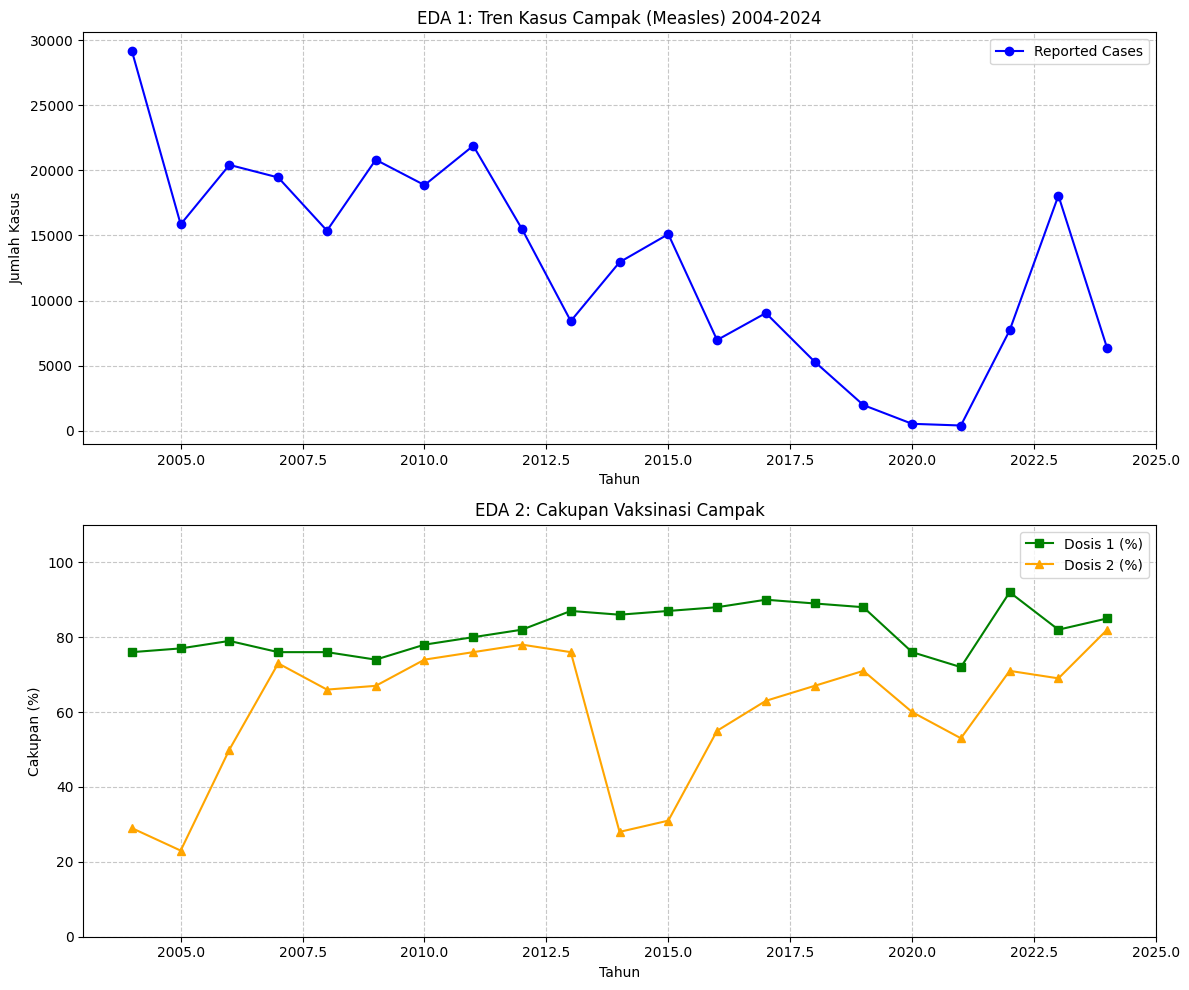

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. Load Data ---
df = pd.read_csv(filepath)
df['Measles_Reported_cases'] = df['Measles_Reported_cases'].astype(str).str.replace(',', '').astype(float)
df['p'] = df['WUENIC_Measles_containing vaccine_1st_dose(%)'] / 100.0
df['q'] = df['WUENIC_Measles_containing vaccine_2nd_dose(%)'] / 100.0
df = df.sort_values('Year').reset_index(drop=True)

# --- 2. EDA: Visualization ---
plt.figure(figsize=(12, 10))

# Subplot 1: Cases
plt.subplot(2, 1, 1)
plt.plot(df['Year'], df['Measles_Reported_cases'], marker='o', color='b', label='Reported Cases')
plt.title('EDA 1: Tren Kasus Campak (Measles) 2004-2024')
plt.xlabel('Tahun')
plt.ylabel('Jumlah Kasus')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

# Subplot 2: Vaccination
plt.subplot(2, 1, 2)
plt.plot(df['Year'], df['p']*100, marker='s', color='g', label='Dosis 1 (%)')
plt.plot(df['Year'], df['q']*100, marker='^', color='orange', label='Dosis 2 (%)')
plt.title('EDA 2: Cakupan Vaksinasi Campak')
plt.xlabel('Tahun')
plt.ylabel('Cakupan (%)')
plt.ylim(0, 110)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.savefig('measles_eda_plot.png')

# --- 3. EKF Implementation (Re-run to get metrics) ---
# Data Prep (Monthly Interpolation)
years = df['Year'].values
months = []
for y in years:
    for m in range(12):
        months.append(y + m/12.0)
df_monthly = pd.DataFrame({'Time': months})

f_p = interp1d(df['Year'], df['p'], kind='linear', fill_value="extrapolate")
f_q = interp1d(df['Year'], df['q'], kind='linear', fill_value="extrapolate")
f_v = interp1d(df['Year'], df['Measles_Reported_cases'], kind='linear', fill_value="extrapolate")

df_monthly['p'] = f_p(df_monthly['Time'])
df_monthly['q'] = f_q(df_monthly['Time'])
df_monthly['V_obs'] = f_v(df_monthly['Time']).clip(min=0)

# Parameters
N = 270000000.0
mu = 0.014
Lambda = mu * N
r = 26.0
epsilon = 0.1
d = 0.001
phi = 12.0
kappa = 0.9
alpha = 0.5
dt = 1.0/12.0

# Init
x = np.array([0.9*N, df_monthly['V_obs'].iloc[0], 0.0, N - 0.9*N - df_monthly['V_obs'].iloc[0], 300.0])
P = np.eye(5) * 1e4
P[4, 4] = 1e2
Q = np.diag([1e2, 1e2, 1e2, 1e2, 10.0])
R_noise = np.array([[1e6]])
H = np.zeros((1, 5))
H[0, 1] = 1

results = []
for index, row in df_monthly.iterrows():
    p_t, q_t, y_obs = row['p'], row['q'], row['V_obs']
    U, V, W, Z, beta = x
    C_vac = (1 - q_t) + alpha * q_t

    # Predict
    U_new = U + dt * ((1 - kappa * p_t) * Lambda - beta * C_vac * U * V / N - mu * U)
    V_new = V + dt * (beta * C_vac * U * V / N - (r + epsilon + mu + d) * V)
    W_new = W + dt * (epsilon * V - (phi + mu + d) * W)
    Z_new = Z + dt * (kappa * p_t * Lambda + r * V + phi * W - mu * Z)
    beta_new = beta
    x_pred = np.array([U_new, V_new, W_new, Z_new, beta_new])

    # Jacobian
    F = np.eye(5)
    F[0,0] = 1 + dt*(-beta*C_vac*V/N - mu)
    F[0,1] = dt*(-beta*C_vac*U/N)
    F[0,4] = dt*(-C_vac*U*V/N)
    F[1,0] = dt*(beta*C_vac*V/N)
    F[1,1] = 1 + dt*(beta*C_vac*U/N - (r+epsilon+mu+d))
    F[1,4] = dt*(C_vac*U*V/N)
    F[2,1] = dt*epsilon
    F[2,2] = 1 - dt*(phi+mu+d)
    F[3,1] = dt*r
    F[3,2] = dt*phi
    F[3,3] = 1 - dt*mu

    P_pred = F @ P @ F.T + Q

    # Update
    y_pred = x_pred[1]
    y_residual = y_obs - y_pred
    S = H @ P_pred @ H.T + R_noise
    K = P_pred @ H.T @ np.linalg.inv(S)
    x = x_pred + (K * y_residual).flatten()
    P = (np.eye(5) - K @ H) @ P_pred
    results.append(x[1])

df_monthly['Est_V'] = results

# --- 4. Evaluation Metrics ---
y_true = df_monthly['V_obs'].values
y_pred = df_monthly['Est_V'].values

# RMSE
mse = np.mean((y_true - y_pred)**2)
rmse = np.sqrt(mse)

# NRMSE (Normalized by mean of observed data)
nrmse = rmse / np.mean(y_true)

# MAPE (Mean Absolute Percentage Error)
# Add small epsilon to avoid division by zero if cases are 0
epsilon_mape = 1e-10
mape = np.mean(np.abs((y_true - y_pred) / (y_true + epsilon_mape))) * 100

print(f"METRICS_RESULT: RMSE={rmse:.4f}, NRMSE={nrmse:.4f}, MAPE={mape:.4f}%")